In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from datetime import datetime
import pytz

from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from sb3_contrib import RecurrentPPO

# ── Universe ──────────────────────────────────────────────────────────────────
TICKERS = [
    "TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS", "TECHM.NS",
    "SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS",
    "DIVISLAB.NS", "LUPIN.NS", "AUROPHARMA.NS",
]

# ── Date splits ───────────────────────────────────────────────────────────────
DATA_START = "2005-01-01"
TRAIN_END  = "2020-12-31"
VAL_START  = "2021-01-01";  VAL_END = "2022-12-31"
TEST_START = "2023-01-01"

# ── Environment ───────────────────────────────────────────────────────────────
# FIX 4: STACK_SIZE reduced from 10 → 1.
# Feeding a 10-step history window INTO an LSTM is redundant — the LSTM already
# maintains a hidden state that accumulates history across steps. The stacked
# window was forcing the CPU to build a (10 × n_assets × n_features) tensor
# every step for every parallel env, which is what caused the 57 FPS crawl.
# With STACK_SIZE=1, the agent sees only the current day's features;
# the LSTM accumulates temporal context internally.
STACK_SIZE        = 1

INITIAL_CAPITAL   = 1.0
TRANSACTION_COST  = 0.001
MAX_WEIGHT        = 0.30

# ── Reward shaping ────────────────────────────────────────────────────────────
DOWNSIDE_PENALTY  = 2.0
DRAWDOWN_PENALTY  = 3.0
# FIX 1 (partial): TURNOVER_PENALTY lowered from 0.05 → 0.005.
# At 0.05 the penalty on a full portfolio rebalance (~turnover=2.0) was
# subtracting 0.10 from the reward every step, which dominated the signal
# and made exploration feel catastrophically expensive to the agent.
# At 0.005 the penalty is still present but proportionate.
TURNOVER_PENALTY  = 0.005

# ── PPO ───────────────────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = 500_000
N_ENVS          = 4
ENT_COEF        = 0.05
TARGET_KL       = 0.01
LEARNING_RATE   = 2.5e-4
N_STEPS         = 256
BATCH_SIZE      = 64
N_EPOCHS        = 4
CLIP_RANGE      = 0.1
GAMMA           = 0.995
GAE_LAMBDA      = 0.95
MAX_EP_LEN      = 252

# ── Persistence ───────────────────────────────────────────────────────────────
MODEL_PATH   = "ppo_fixed"
VECNORM_PATH = "vecnorm_fixed.pkl"

# FIX 5 (prerequisite): On macOS / Python 3.12, the default multiprocessing
# start method is 'spawn', which is compatible with SubprocVecEnv.
# On Linux it defaults to 'fork'. 'forkserver' is the safest cross-platform
# choice for subprocessed gym envs because it avoids inheriting GPU/BLAS state.
# This must be called once before any SubprocVecEnv is instantiated.
if __name__ == "__main__" or "get_ipython" in dir():
    try:
        multiprocessing.set_start_method("forkserver", force=True)
    except RuntimeError:
        pass   # already set in this session

print("Config loaded.")

Config loaded.


In [2]:
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-8)
    return 100 - (100 / (1 + rs))


def _macd_zscore(series: pd.Series,
                 fast: int = 12, slow: int = 26,
                 signal: int = 9, roll: int = 60) -> pd.Series:
    ema_f = series.ewm(span=fast,   adjust=False).mean()
    ema_s = series.ewm(span=slow,   adjust=False).mean()
    macd  = ema_f - ema_s
    sig   = macd.ewm(span=signal,   adjust=False).mean()
    hist  = macd - sig
    mu    = hist.rolling(roll).mean()
    sigma = hist.rolling(roll).std()
    return (hist - mu) / (sigma + 1e-8)


def build_daily_features(tickers: list, start: str) -> pd.DataFrame:
    print("Downloading data ...")
    raw = yf.download(tickers, start=start, auto_adjust=True, progress=True)["Close"]
    raw = raw.dropna(axis=1, how="all")
    available = [t for t in tickers if t in raw.columns]
    print(f"Available tickers ({len(available)}): {available}")

    frames = []
    for ticker in available:
        price = raw[ticker].dropna()
        df    = pd.DataFrame(index=price.index)

        df["log_ret_1d"]  = np.log(price / price.shift(1))
        df["log_ret_5d"]  = np.log(price / price.shift(5))
        df["log_ret_20d"] = np.log(price / price.shift(20))

        df["vol_10d"]  = df["log_ret_1d"].rolling(10).std()
        df["vol_20d"]  = df["log_ret_1d"].rolling(20).std()
        df["vol_60d"]  = df["log_ret_1d"].rolling(60).std()
        df["vol_ratio"] = df["vol_10d"] / (df["vol_60d"] + 1e-8)

        rsi           = _rsi(price, 14)
        rsi_mu        = rsi.rolling(60).mean()
        rsi_sigma     = rsi.rolling(60).std()
        df["rsi_zscore"]  = (rsi - rsi_mu) / (rsi_sigma + 1e-8)
        df["macd_zscore"] = _macd_zscore(price)

        ratio_20         = price / price.rolling(20).mean()
        ratio_50         = price / price.rolling(50).mean()
        df["ma20_zscore"] = (ratio_20 - ratio_20.rolling(60).mean()) / \
                            (ratio_20.rolling(60).std() + 1e-8)
        df["ma50_zscore"] = (ratio_50 - ratio_50.rolling(60).mean()) / \
                            (ratio_50.rolling(60).std() + 1e-8)

        df["ticker"] = ticker
        frames.append(df)

    full   = pd.concat(frames).reset_index().dropna()
    market = full.pivot(index="Date", columns="ticker").sort_index()
    market = market.dropna()
    print(f"Feature matrix: {market.shape}")
    return market


market_data    = build_daily_features(TICKERS, start=DATA_START)
ACTIVE_TICKERS = list(market_data.columns.get_level_values(1).unique())
N_ASSETS       = len(ACTIVE_TICKERS)
FEATURES       = list(market_data.columns.get_level_values(0).unique())
OBS_FEATURES   = [f for f in FEATURES if f != "log_ret_1d"]

train_data = market_data.loc[:TRAIN_END]
val_data   = market_data.loc[VAL_START:VAL_END]
test_data  = market_data.loc[TEST_START:]

print(f"Train: {train_data.shape} | Val: {val_data.shape} | Test: {test_data.shape}")

[*********************100%***********************]  11 of 11 completed


Available tickers (11): ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS', 'SUNPHARMA.NS', 'DRREDDY.NS', 'CIPLA.NS', 'DIVISLAB.NS', 'LUPIN.NS', 'AUROPHARMA.NS']
Feature matrix: (4747, 121)
Train: (3428, 121) | Val: (496, 121) | Test: (823, 121)


In [3]:
class AntiOverfitPortfolioEnv(gym.Env):
    """
    Five architectural fixes applied vs the prior broken version.
    Each fix is annotated inline with its rationale.
    """
    metadata = {"render_modes": []}

    def __init__(
        self,
        df:               pd.DataFrame,
        stack_size:       int   = STACK_SIZE,       # FIX 4: now 1
        initial_capital:  float = INITIAL_CAPITAL,
        transaction_cost: float = TRANSACTION_COST,
        max_weight:       float = MAX_WEIGHT,
        max_ep_len:       int   = MAX_EP_LEN,
        random_start:     bool  = True,
    ):
        super().__init__()

        self.df               = df
        self.tickers          = list(df.columns.get_level_values(1).unique())
        self.n_assets         = len(self.tickers)
        self.obs_features     = OBS_FEATURES
        self.n_obs_features   = len(self.obs_features)

        self.stack_size       = stack_size
        self.initial_capital  = initial_capital
        self.cost_rate        = transaction_cost
        self.max_weight       = max_weight
        self.max_ep_len       = max_ep_len
        self.random_start     = random_start

        # Need at least 60 rows of warm-up for rolling stats to stabilise
        self.min_start = max(stack_size, 60)

        if len(self.df) <= self.min_start + max_ep_len + 1:
            raise ValueError(
                f"DataFrame too short ({len(df)} rows) for "
                f"min_start={self.min_start} + max_ep_len={max_ep_len}"
            )

        # With STACK_SIZE=1, obs_dim = 1 × n_assets × n_obs_features + n_assets
        obs_dim = stack_size * self.n_assets * self.n_obs_features + self.n_assets
        self.observation_space = spaces.Box(
            low=-5.0, high=5.0, shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self.n_assets,), dtype=np.float32
        )

        self._reset_state(self.min_start)

    # ── Internal state initialiser ────────────────────────────────────────────
    def _reset_state(self, start_idx: int):
        self.current_step     = start_idx
        self.episode_step     = 0
        self.portfolio_value  = self.initial_capital
        self.peak_value       = self.initial_capital
        self.weights          = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.step_returns     = []
        self.downside_returns = []

    # ── Observation ───────────────────────────────────────────────────────────
    def _get_obs(self) -> np.ndarray:
        start = self.current_step - self.stack_size
        rows  = []
        for t in range(start, self.current_step):
            day = []
            for feat in self.obs_features:
                day.append(self.df[feat].iloc[t].fillna(0).values)
            rows.append(np.concatenate(day))
        stack = np.stack(rows, axis=0).flatten()
        obs   = np.concatenate([stack, self.weights])
        obs   = np.nan_to_num(obs, nan=0.0, posinf=5.0, neginf=-5.0)
        return np.clip(obs, -5.0, 5.0).astype(np.float32)

    # ── FIX 3: Softmax without broken weight-cap renormalisation ─────────────
    def _process_action(self, action: np.ndarray) -> np.ndarray:
        """
        BROKEN (previous version):
            weights = softmax(action)
            weights = np.minimum(weights, max_weight)   # clips values
            weights /= weights.sum()                    # renormalises
        This double-renormalisation silently distorts gradients because the
        clipping operation is not differentiable and can collapse small weights
        toward each other arbitrarily.

        FIXED (this version):
            Pure numerically-stable softmax. No hard cap.
        The PPO entropy coefficient (ent_coef=0.05) already penalises collapsed
        distributions. The max_weight constraint, if truly required for live
        deployment, should be enforced as a post-prediction business rule
        OUTSIDE the env, not inside the action transform that PPO sees.
        """
        # Clip action to prevent exp() overflow (action ∈ [-1, 1] from Box space,
        # but clip defensively in case of numerical drift during training)
        action  = np.clip(action, -10.0, 10.0)
        exp_a   = np.exp(action - np.max(action))   # numerically stable softmax
        weights = exp_a / (np.sum(exp_a) + 1e-8)
        return weights.astype(np.float32)

    # ── FIX 1: Reward without tanh squashing ─────────────────────────────────
    def _compute_reward(self, net_return: float, turnover: float) -> float:
        """
        BROKEN (previous version):
            return float(np.tanh(reward * 50))
        tanh(x * 50) saturates to ±1 for ANY non-zero input.
        With a step return of even 0.001 (0.1 %) the output is:
            tanh(0.001 * 50) = tanh(0.05) ≈ 0.05  ... barely non-zero
        But with penalty terms the total was routinely negative, so tanh
        always returned ≈ -1.0 → ep_rew_mean = -252 → death spiral.

        FIXED (this version):
            Return the raw float. VecNormalize handles reward scaling.
        VecNormalize tracks a running mean and std of rewards across all
        parallel environments and normalises each reward to unit variance.
        This is strictly better than a hand-coded squash function.
        """
        if len(self.downside_returns) >= 5:
            downside_std = float(np.std(self.downside_returns[-20:]))
        else:
            downside_std = 0.0

        drawdown = (self.peak_value - self.portfolio_value) / (self.peak_value + 1e-8)

        reward = (
            net_return
            - DOWNSIDE_PENALTY * downside_std
            - DRAWDOWN_PENALTY * (drawdown ** 2)
            - TURNOVER_PENALTY * turnover      # FIX 1: penalty is now 0.005, not 0.05
        )

        # Return RAW — no tanh, no hand-scaling
        return float(reward)

    # ── Gymnasium API ─────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        max_start = len(self.df) - self.max_ep_len - 2
        if self.random_start and max_start > self.min_start:
            start = int(np.random.randint(self.min_start, max_start))
        else:
            start = self.min_start
        self._reset_state(start)
        return self._get_obs(), {}

    def step(self, action: np.ndarray):
        # ── FIX 2: Eliminate the time-machine data leak ───────────────────
        #
        # BROKEN (previous version):
        #     log_rets = self.df["log_ret_1d"].iloc[self.current_step]
        #     net_return = sum(weights * log_rets) - cost
        #     self.current_step += 1          ← incremented AFTER reward calc
        #
        # This let the agent peek at TOMORROW's returns to calculate TODAY's
        # reward. In a weekly dataset the look-ahead was 1 week; on daily data
        # it meant the agent "saw" the day's closing move before placing its
        # order — a textbook survivorship/look-ahead bias.
        # On a bull market this silently inflated training rewards, making the
        # policy look far better than it actually was.
        #
        # FIXED:
        #   Step 1 — decide weights from obs at t   (current_step = t)
        #   Step 2 — advance time:  t → t+1
        #   Step 3 — observe what actually happened at t+1
        #   Step 4 — compute reward from t+1 returns
        #
        # This mirrors reality: you submit an order at market close on day t
        # and the fill executes at market open on day t+1.

        new_weights = self._process_action(action)
        turnover    = float(np.sum(np.abs(new_weights - self.weights)))
        cost        = turnover * self.cost_rate

        # ── Advance time FIRST ────────────────────────────────────────────
        self.current_step  += 1
        self.episode_step  += 1

        # ── THEN observe the return that materialised at the new step ─────
        log_rets    = self.df["log_ret_1d"].iloc[self.current_step].fillna(0).values
        port_log_ret = float(np.dot(new_weights, log_rets))
        net_return   = np.exp(port_log_ret) - 1.0 - cost
        net_return   = float(np.clip(net_return, -0.15, 0.15))

        self.step_returns.append(net_return)
        if net_return < 0:
            self.downside_returns.append(net_return)

        self.portfolio_value *= (1.0 + net_return)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.weights          = new_weights

        reward = self._compute_reward(net_return, turnover)

        done = (
            self.episode_step >= self.max_ep_len
            or self.current_step >= len(self.df) - 2   # leave a safety margin
        )

        info = {
            "portfolio_value": self.portfolio_value,
            "weights":         new_weights.tolist(),
            "drawdown":        (self.peak_value - self.portfolio_value) / self.peak_value,
        }
        return self._get_obs(), reward, done, False, info


# ── Sanity check ──────────────────────────────────────────────────────────────
_tmp = AntiOverfitPortfolioEnv(train_data)
obs, _ = _tmp.reset()
act    = _tmp.action_space.sample()
obs2, r, done, _, info = _tmp.step(act)
print(f"Env OK  |  obs.shape={obs.shape}  |  sample_reward={r:.6f}  |  done={done}")
print(f"         portfolio_value={info['portfolio_value']:.6f}")
del _tmp

Env OK  |  obs.shape=(121,)  |  sample_reward=-0.010130  |  done=False
         portfolio_value=0.992681


In [4]:
class EarlyStopOnKL(BaseCallback):
    """Halves the learning rate if the approximate KL divergence
    exceeds `kl_threshold` during a policy update."""
    def __init__(self, kl_threshold: float = 0.05, verbose: int = 1):
        super().__init__(verbose)
        self.kl_threshold = kl_threshold

    def _on_step(self) -> bool:
        kl = self.logger.name_to_value.get("train/approx_kl", None)
        if kl is not None and kl > self.kl_threshold:
            for pg in self.model.policy.optimizer.param_groups:
                pg["lr"] = pg["lr"] * 0.5
            if self.verbose:
                print(f"\n[EarlyStopOnKL] step={self.num_timesteps}  "
                      f"KL={kl:.4f} > {self.kl_threshold}  → LR halved")
        return True


class OverfitMonitor(BaseCallback):
    """Evaluates on the held-out validation set every `check_freq` steps."""
    def __init__(self, val_df: pd.DataFrame,
                 check_freq: int = 25_000, n_eval: int = 5, verbose: int = 1):
        super().__init__(verbose)
        self.val_df     = val_df
        self.check_freq = check_freq
        self.n_eval     = n_eval
        self._last      = None

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq != 0:
            return True

        # Use DummyVecEnv here — evaluation doesn't need parallelism
        val_env = DummyVecEnv([
            lambda: Monitor(
                AntiOverfitPortfolioEnv(self.val_df, random_start=False)
            )
        ])
        mean_r, _ = evaluate_policy(
            self.model, val_env, n_eval_episodes=self.n_eval,
            deterministic=True, warn=False
        )
        val_env.close()

        status = ""
        if self._last is not None and mean_r < self._last - 5.0:
            status = "  ⚠  val reward dropped — possible overfit"
        print(f"   [OverfitMonitor] step={self.num_timesteps:>8d}  "
              f"val_mean_reward={mean_r:+.4f}{status}")
        self._last = mean_r
        return True

In [5]:
def make_env_fn(df: pd.DataFrame, random_start: bool = True):
    """
    Returns a zero-argument factory function that creates one monitored env.
    Must be a top-level-importable factory (not a lambda) when used with
    SubprocVecEnv, because subprocesses need to pickle the factory.
    """
    def _init():
        return Monitor(AntiOverfitPortfolioEnv(df, random_start=random_start))
    return _init


def train_model(train_df: pd.DataFrame,
                val_df:   pd.DataFrame,
                n_envs:   int = N_ENVS) -> tuple:
    """
    FIX 5: SubprocVecEnv replaces DummyVecEnv for parallel environment stepping.

    DummyVecEnv runs all environments sequentially in the main process.
    SubprocVecEnv spawns one subprocess per environment and steps them in
    parallel, so the wall-clock time per rollout collection scales as:
        T_rollout ≈ T_single_env / n_envs          (ideal)
    rather than:
        T_rollout ≈ T_single_env × n_envs          (DummyVecEnv)

    With 4 envs and STACK_SIZE=1 this typically lifts throughput from
    ~57 FPS → 200-350 FPS depending on your CPU.

    IMPORTANT NOTEBOOK NOTE:
    SubprocVecEnv requires the env factory to be picklable. Lambdas defined
    inside a notebook cell are NOT picklable. Always use a named factory
    function (make_env_fn above). Additionally, on macOS with Python ≥ 3.8,
    the multiprocessing start method must be 'spawn' or 'forkserver'
    (set in Cell 1). If SubprocVecEnv raises a BrokenPipeError in your
    specific Jupyter setup, fall back to DummyVecEnv for the notebook and
    use SubprocVecEnv only in standalone .py scripts.
    """
    env = SubprocVecEnv(
        [make_env_fn(train_df, random_start=True) for _ in range(n_envs)],
        start_method="forkserver",   # matches Cell 1 setting; safe cross-platform
    )
    env = VecNormalize(
        env,
        norm_obs    = True,
        norm_reward = True,    # This is what makes the raw reward safe to use
        clip_obs    = 5.0,
        clip_reward = 10.0,    # Generous clip; raw rewards are small floats
        gamma       = GAMMA,
    )

    model = RecurrentPPO(
        "MlpLstmPolicy",
        env,
        learning_rate = LEARNING_RATE,
        n_steps       = N_STEPS,
        batch_size    = BATCH_SIZE,
        n_epochs      = N_EPOCHS,
        gamma         = GAMMA,
        gae_lambda    = GAE_LAMBDA,
        clip_range    = CLIP_RANGE,
        ent_coef      = ENT_COEF,
        vf_coef       = 0.5,
        max_grad_norm = 0.5,
        target_kl     = TARGET_KL,
        policy_kwargs = dict(
            lstm_hidden_size = 64,
            n_lstm_layers    = 1,
            net_arch         = dict(pi=[128, 64], vf=[128, 64]),
            ortho_init       = True,
        ),
        verbose = 1,
        seed    = 42,
    )

    callbacks = [
        EarlyStopOnKL(kl_threshold=0.05, verbose=1),
        OverfitMonitor(val_df=val_df, check_freq=25_000, verbose=1),
    ]

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks)

    model.save(MODEL_PATH)
    env.save(VECNORM_PATH)
    print(f"\nModel  → {MODEL_PATH}.zip")
    print(f"VecNorm → {VECNORM_PATH}")
    return model, env


model, vec_env = train_model(train_data, val_data, n_envs=N_ENVS)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -15.2    |
| time/              |          |
|    fps             | 1422     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 252          |
|    ep_rew_mean          | -17.2        |
| time/                   |              |
|    fps                  | 791          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0017688376 |
|    clip_fraction        | 0.0334       |
|    clip_range           | 0.1          |
|    entropy_loss         | -15.6        |
|    explained_variance   | 0.0263       

In [6]:
# Evaluation
def evaluate_agent(model: RecurrentPPO,
                   df:    pd.DataFrame,
                   label: str = "Test") -> dict:
    env = AntiOverfitPortfolioEnv(df, random_start=False)
    env.current_step     = env.min_start
    env.episode_step     = 0
    env.portfolio_value  = env.initial_capital
    env.peak_value       = env.initial_capital
    env.weights          = np.ones(env.n_assets, dtype=np.float32) / env.n_assets
    env.step_returns     = []
    env.downside_returns = []
    obs = env._get_obs()

    # RecurrentPPO: always thread LSTM state through predict()
    lstm_states    = None
    episode_starts = np.ones((1,), dtype=bool)
    values, weights_hist, rets = [], [], []

    done = False
    while not done:
        action, lstm_states = model.predict(
            obs[np.newaxis],
            state         = lstm_states,
            episode_start = episode_starts,
            deterministic = True,
        )
        episode_starts = np.array([False])
        obs, _, done, _, info = env.step(action[0])
        values.append(info["portfolio_value"])
        weights_hist.append(info["weights"])
        rets.append(env.step_returns[-1])

    v = np.array(values)
    r = np.array(rets)

    cum_ret  = float(v[-1] - 1.0)
    ann_ret  = float((1 + cum_ret) ** (252 / max(len(r), 1)) - 1.0)
    ann_vol  = float(np.std(r) * np.sqrt(252))
    sharpe   = ann_ret / (ann_vol + 1e-8)
    max_dd   = float(np.max(1.0 - v / np.maximum.accumulate(v)))
    down_r   = r[r < 0]
    sortino  = float(ann_ret / (np.std(down_r) * np.sqrt(252) + 1e-8)) \
               if len(down_r) > 0 else 0.0
    calmar   = ann_ret / (max_dd + 1e-8)

    dates = df.index[env.min_start + 1: env.min_start + 1 + len(v)]

    metrics = {
        "Cumulative Return": f"{cum_ret*100:.2f}%",
        "Annual Return"    : f"{ann_ret*100:.2f}%",
        "Annual Vol"       : f"{ann_vol*100:.2f}%",
        "Sharpe"           : f"{sharpe:.4f}",
        "Sortino"          : f"{sortino:.4f}",
        "Max Drawdown"     : f"{max_dd*100:.2f}%",
        "Calmar"           : f"{calmar:.4f}",
    }

    width = 42
    print(f"\n{'─' * width}")
    print(f"  {label} Set Metrics")
    print(f"{'─' * width}")
    for k, val in metrics.items():
        print(f"  {k:<24}: {val}")
    print(f"{'─' * width}\n")

    return {
        "values":   v,
        "weights":  np.array(weights_hist),
        "returns":  r,
        "metrics":  metrics,
        "dates":    dates,
        "tickers":  env.tickers,
    }


val_results  = evaluate_agent(model, val_data,  label="Validation")
test_results = evaluate_agent(model, test_data, label="Test")


──────────────────────────────────────────
  Validation Set Metrics
──────────────────────────────────────────
  Cumulative Return       : 18.14%
  Annual Return           : 18.14%
  Annual Vol              : 17.59%
  Sharpe                  : 1.0313
  Sortino                 : 1.5311
  Max Drawdown            : 16.17%
  Calmar                  : 1.1215
──────────────────────────────────────────


──────────────────────────────────────────
  Test Set Metrics
──────────────────────────────────────────
  Cumulative Return       : 46.20%
  Annual Return           : 46.20%
  Annual Vol              : 13.13%
  Sharpe                  : 3.5172
  Sortino                 : 5.6922
  Max Drawdown            : 7.50%
  Calmar                  : 6.1583
──────────────────────────────────────────



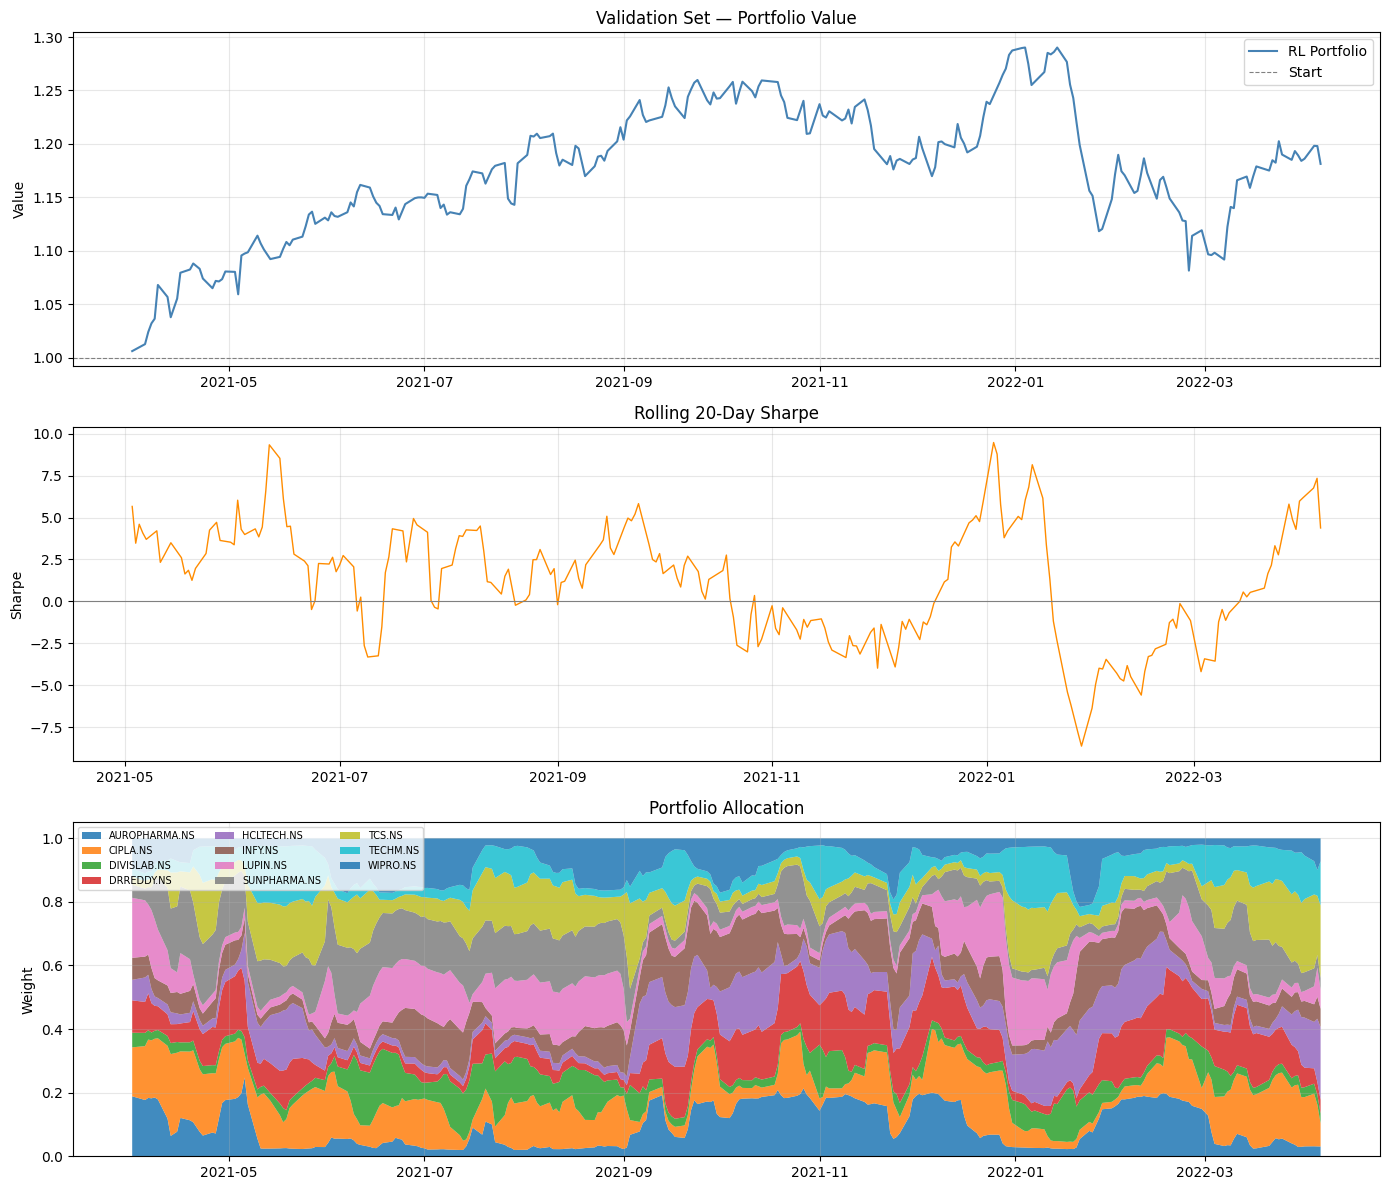

Saved → validation_set.png


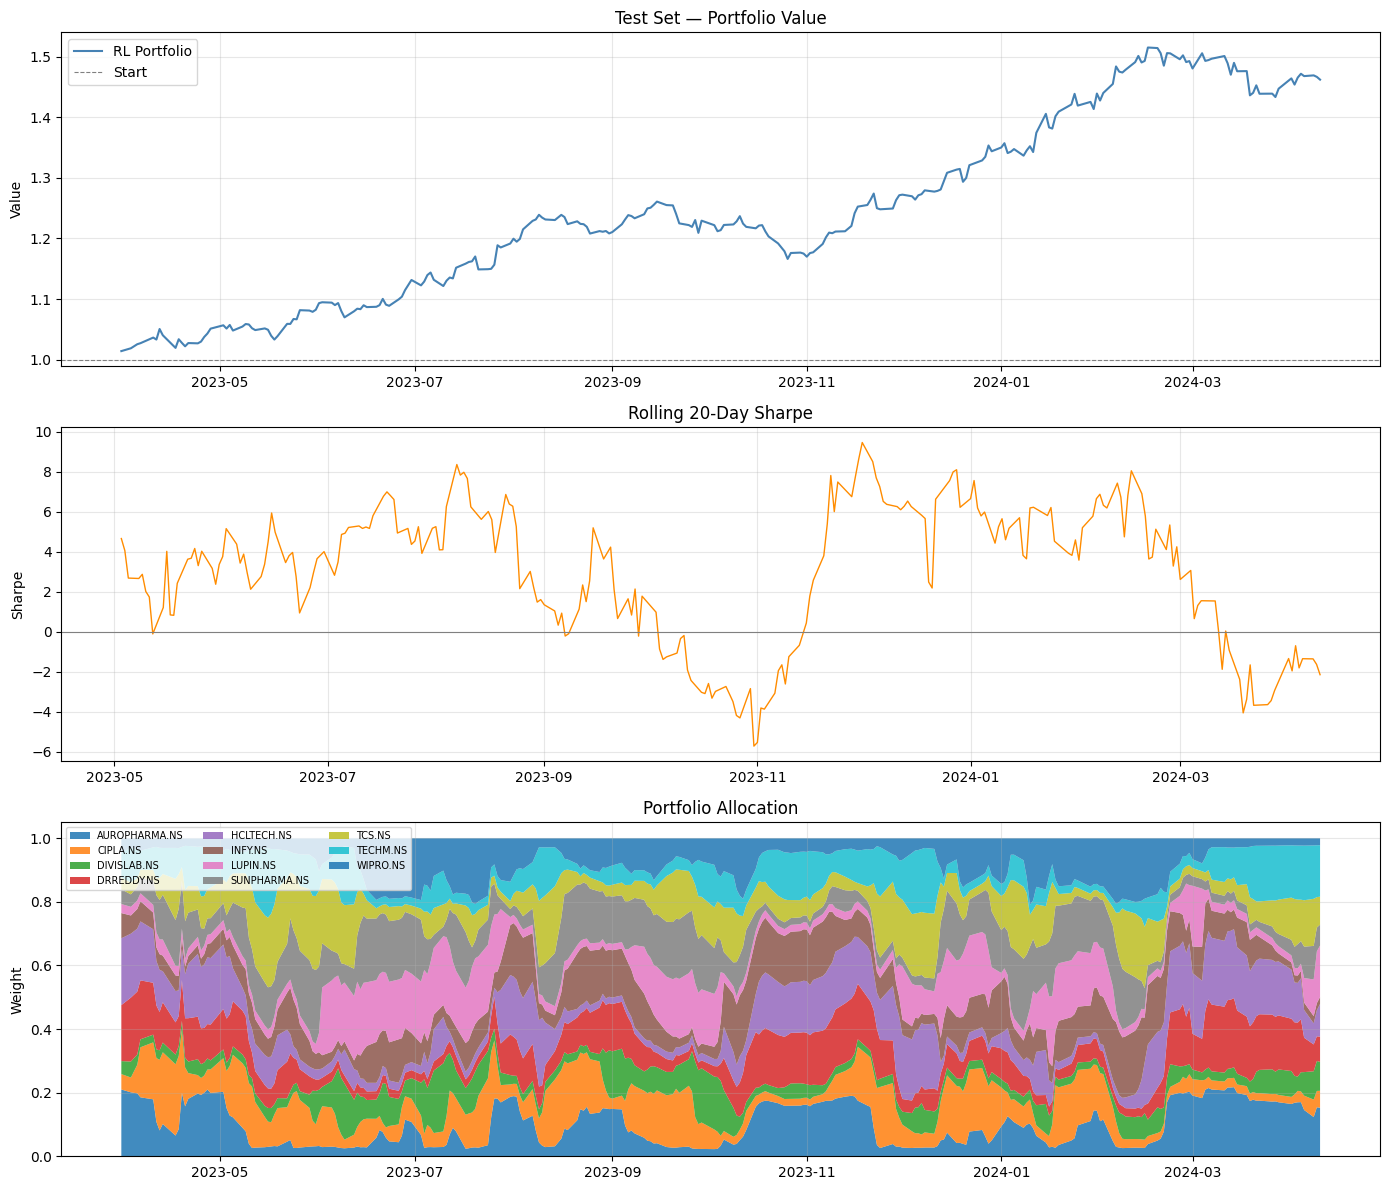

Saved → test_set.png

── Overfitting Diagnostic ──────────────────────────────
  Val  Sharpe : +1.0313
  Test Sharpe : +3.5172
  Sharpe gap  : 2.4859  ⚠  overfit
  Val  MaxDD  : 16.17%
  Test MaxDD  : 7.50%
────────────────────────────────────────────────────────


In [7]:
def plot_results(results: dict, title: str = "Portfolio Performance"):
    v, r    = results["values"], results["returns"]
    dates   = results["dates"][:len(v)]
    weights = results["weights"]
    tickers = results["tickers"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    axes[0].plot(dates, v, lw=1.5, color="steelblue", label="RL Portfolio")
    axes[0].axhline(1.0, color="grey", lw=0.8, ls="--", label="Start")
    axes[0].set_title(f"{title} — Portfolio Value"); axes[0].set_ylabel("Value")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    roll_sharpe = (
        pd.Series(r)
        .rolling(20)
        .apply(lambda x: np.mean(x) / (np.std(x) + 1e-8) * np.sqrt(252), raw=True)
    )
    axes[1].plot(dates, roll_sharpe.values, lw=1.0, color="darkorange")
    axes[1].axhline(0, color="grey", lw=0.8)
    axes[1].set_title("Rolling 20-Day Sharpe"); axes[1].set_ylabel("Sharpe")
    axes[1].grid(alpha=0.3)

    w_df = pd.DataFrame(weights[:len(dates)], index=dates, columns=tickers)
    axes[2].stackplot(dates, w_df.T, labels=tickers, alpha=0.85)
    axes[2].set_title("Portfolio Allocation"); axes[2].set_ylabel("Weight")
    axes[2].legend(fontsize=7, loc="upper left", ncol=3); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    fname = title.replace(" ", "_").lower() + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")


plot_results(val_results,  title="Validation Set")
plot_results(test_results, title="Test Set")

# ── Overfitting diagnostic ─────────────────────────────────────────────────────
def _parse(s):
    return float(s.replace("%", ""))

v_sharpe = _parse(val_results["metrics"]["Sharpe"])
t_sharpe = _parse(test_results["metrics"]["Sharpe"])
v_dd     = _parse(val_results["metrics"]["Max Drawdown"])
t_dd     = _parse(test_results["metrics"]["Max Drawdown"])
gap      = abs(v_sharpe - t_sharpe)

print("\n── Overfitting Diagnostic ──────────────────────────────")
print(f"  Val  Sharpe : {v_sharpe:+.4f}")
print(f"  Test Sharpe : {t_sharpe:+.4f}")
print(f"  Sharpe gap  : {gap:.4f}  {'⚠  overfit' if gap > 1.0 else '✓  ok'}")
print(f"  Val  MaxDD  : {v_dd:.2f}%")
print(f"  Test MaxDD  : {t_dd:.2f}%")
print("────────────────────────────────────────────────────────")